# VIX SPX Replication

**Issue:** M0 #3
**Spec source:** `docs/vix-notes.md`

## Goal

Implement the CBOE VIX variance-swap methodology end-to-end in Python and verify it
on (a) synthetic Black-Scholes-priced chains where the answer is known a-priori, and
(b) real published SPX option chains where the result must match the published VIX
within ±0.5 pts on ≥95% of historical days.

This notebook is the **truth oracle** for the Rust engine implementation in M1.

## Outline

1. Black-Scholes helpers (forward-quoted Black-76).
2. Synthetic chain generator.
3. VIX components — forward, K₀, OTM strip, ΔK, variance integral, 30-day interpolation.
4. End-to-end `compute_vix(...)` function.
5. Sanity check — constant-IV chain ⇒ VIX = IV·100.
6. IV sweep — computed VIX tracks input IV across 10–50% range.
7. Real-data backtest (TODO — pending data source wiring).


## 1. Imports + paths


In [1]:
from __future__ import annotations
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

DATA = Path('data/spx')
DATA.mkdir(parents=True, exist_ok=True)

N365 = 365 * 1440  # minutes in a year (CBOE convention)
N30  =  30 * 1440  # minutes in 30 days


## 2. Black-Scholes (Black-76) helpers

We use Black-76 (forward-quoted) so the inputs are $(F, K, T, r, \sigma)$ and the
output is the present-value option price. The forward $F$ is given; in the synthetic
generator below we set $F$ exogenously and re-derive it from put-call parity to verify
our forward extraction logic.


In [2]:
def _d1(F, K, T, sigma):
    return (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))

def _d2(F, K, T, sigma):
    return _d1(F, K, T, sigma) - sigma * np.sqrt(T)

def bs_call(F, K, T, r, sigma):
    d1, d2 = _d1(F, K, T, sigma), _d2(F, K, T, sigma)
    return np.exp(-r * T) * (F * norm.cdf(d1) - K * norm.cdf(d2))

def bs_put(F, K, T, r, sigma):
    d1, d2 = _d1(F, K, T, sigma), _d2(F, K, T, sigma)
    return np.exp(-r * T) * (K * norm.cdf(-d2) - F * norm.cdf(-d1))


## 3. Synthetic option chain generator

A constant-IV BS chain — by no-arb construction the implementation should recover
$\text{VIX} = 100\sigma$ from any such chain. Discretization error from a finite strike
grid is the only deviation, and shrinks with finer / wider grids.


In [3]:
@dataclass
class Chain:
    T: float                 # time to expiry, years
    r: float                 # risk-free rate
    strikes: np.ndarray      # listed strikes (sorted ascending)
    calls: np.ndarray        # call mids aligned to strikes
    puts:  np.ndarray        # put mids aligned to strikes
    F_true: float | None = None  # ground truth for verification only

def synthetic_chain(F, T, r, sigma, K_lo, K_hi, K_step) -> Chain:
    K = np.arange(K_lo, K_hi + K_step, K_step, dtype=float)
    return Chain(
        T=T, r=r, strikes=K,
        calls=bs_call(F, K, T, r, sigma),
        puts =bs_put (F, K, T, r, sigma),
        F_true=F,
    )


## 4. Forward via put-call parity

$$F = K^* + e^{rT}(C(K^*) - P(K^*))$$

with $K^* = \arg\min_K |C(K) - P(K)|$.


In [4]:
def forward_from_parity(chain: Chain) -> tuple[float, int]:
    diff = np.abs(chain.calls - chain.puts)
    i_star = int(np.argmin(diff))
    F = chain.strikes[i_star] + np.exp(chain.r * chain.T) * (chain.calls[i_star] - chain.puts[i_star])
    return float(F), i_star


## 5. $K_0$ — largest strike $\le F$


In [5]:
def select_k0(strikes: np.ndarray, F: float) -> tuple[float, int]:
    mask = strikes <= F
    if not mask.any():
        raise ValueError(f"no listed strike <= F={F}")
    i0 = int(np.where(mask)[0][-1])
    return float(strikes[i0]), i0


## 6. OTM strip with CBOE zero-bid wing termination

- $K_i < K_0$ → use put mid
- $K_i > K_0$ → use call mid
- $K_i = K_0$ → average of put + call mids

Walking outward from $K_0$, stop at the **first pair of consecutive zero-bid
strikes** and discard both zero strikes plus everything beyond (§4 of the notes).
For Black-Scholes-priced synthetic chains the wing termination is a no-op (no
zero bids); we still apply the rule so real data flows through unchanged.


In [6]:
def _walk_wing(prices: np.ndarray, start_idx: int, direction: int, min_bid: float = 0.0) -> list[int]:
    '''Walk outward from start_idx (exclusive). Discard zero-bid strikes;
    stop at the first pair of consecutive zero-bid strikes.'''
    n = len(prices)
    keep: list[int] = []
    prev_zero = False
    i = start_idx + direction
    while 0 <= i < n:
        is_zero = prices[i] <= min_bid
        if is_zero and prev_zero:
            break
        if not is_zero:
            keep.append(i)
        prev_zero = is_zero
        i += direction
    return keep

def build_otm_strip(chain: Chain, K0: float, i0: int) -> tuple[np.ndarray, np.ndarray]:
    '''Return (K, Q) — the OTM strip after wing termination.'''
    put_idx  = _walk_wing(chain.puts,  i0, direction=-1)
    call_idx = _walk_wing(chain.calls, i0, direction=+1)
    put_idx.sort()           # ascending

    K = np.concatenate([chain.strikes[put_idx], [K0], chain.strikes[call_idx]])
    Q = np.concatenate([
        chain.puts[put_idx],
        [0.5 * (chain.puts[i0] + chain.calls[i0])],
        chain.calls[call_idx],
    ])
    return K, Q


## 7. $\Delta K_i$ — CBOE-spec strike interval

$\Delta K_i = (K_{i+1} - K_{i-1})/2$ for interior strikes; one-sided at edges.


In [7]:
def delta_k_array(K: np.ndarray) -> np.ndarray:
    n = len(K)
    dK = np.empty(n)
    dK[0]  = K[1]  - K[0]
    dK[-1] = K[-1] - K[-2]
    if n > 2:
        dK[1:-1] = 0.5 * (K[2:] - K[:-2])
    return dK


## 8. Variance integral per expiry

$$\sigma_T^2 \;=\; \frac{2 e^{rT}}{T} \sum_i \frac{\Delta K_i}{K_i^2} Q(K_i) \;-\; \frac{1}{T}\!\left(\frac{F}{K_0}-1\right)^2$$


In [8]:
def variance_per_expiry(K: np.ndarray, Q: np.ndarray,
                        F: float, K0: float, T: float, r: float) -> float:
    dK = delta_k_array(K)
    sum_term   = float(np.sum((dK / K**2) * Q))
    correction = ((F / K0 - 1.0) ** 2) / T
    return (2.0 * np.exp(r * T) / T) * sum_term - correction


## 9. 30-day constant-maturity interpolation (total-variance space)

Given near and next expiries with $N_{T_1}, N_{T_2}$ minutes to expiry and
annualized variances $\sigma_1^2, \sigma_2^2$:


In [9]:
def interpolate_30d(N_T1: float, sigma2_1: float,
                    N_T2: float, sigma2_2: float) -> float:
    T1, T2 = N_T1 / N365, N_T2 / N365
    w1 = (N_T2 - N30) / (N_T2 - N_T1)
    w2 = (N30  - N_T1) / (N_T2 - N_T1)
    total_var = T1 * sigma2_1 * w1 + T2 * sigma2_2 * w2
    return float(total_var * (N365 / N30))


## 10. End-to-end `compute_vix(...)`


In [10]:
def compute_vix(near: Chain, next_: Chain, N_T1: float, N_T2: float) -> dict:
    F1, _   = forward_from_parity(near)
    K0_1, i0_1 = select_k0(near.strikes, F1)
    K1, Q1  = build_otm_strip(near, K0_1, i0_1)
    s2_1    = variance_per_expiry(K1, Q1, F1, K0_1, near.T, near.r)

    F2, _   = forward_from_parity(next_)
    K0_2, i0_2 = select_k0(next_.strikes, F2)
    K2, Q2  = build_otm_strip(next_, K0_2, i0_2)
    s2_2    = variance_per_expiry(K2, Q2, F2, K0_2, next_.T, next_.r)

    s2_30d  = interpolate_30d(N_T1, s2_1, N_T2, s2_2)
    return {
        'F1': F1, 'F2': F2,
        'K0_1': K0_1, 'K0_2': K0_2,
        'sigma2_1': s2_1, 'sigma2_2': s2_2,
        'sigma2_30d': s2_30d,
        'vix': 100.0 * np.sqrt(s2_30d),
        'strip_size_1': len(K1),
        'strip_size_2': len(K2),
    }


## 11. Sanity check — constant 20% IV chain

A Black-Scholes-priced chain with $\sigma = 0.20$ should yield $\text{VIX} \approx 20$.
Any deviation is pure discretization error from a finite strike grid.


In [11]:
F0 = 4500.0
r  = 0.05
sigma_true = 0.20

T1 = 23 / 365
T2 = 37 / 365
N_T1 = T1 * N365
N_T2 = T2 * N365

c1 = synthetic_chain(F0, T1, r, sigma_true, K_lo=2500, K_hi=6500, K_step=5)
c2 = synthetic_chain(F0, T2, r, sigma_true, K_lo=2500, K_hi=6500, K_step=5)

res = compute_vix(c1, c2, N_T1, N_T2)
print(f"forward (near)        = {res['F1']:.4f}   (true {F0})")
print(f"K0    (near)          = {res['K0_1']}")
print(f"strip size            = {res['strip_size_1']} strikes (near)")
print(f"sigma^2 (near, annl)  = {res['sigma2_1']:.6f}")
print(f"sigma^2 (next, annl)  = {res['sigma2_2']:.6f}")
print(f"sigma^2 (30d)         = {res['sigma2_30d']:.6f}")
print(f"VIX                   = {res['vix']:.4f}    (expected ~{100*sigma_true:.2f})")


forward (near)        = 4500.0000   (true 4500.0)
K0    (near)          = 4500.0
strip size            = 801 strikes (near)
sigma^2 (near, annl)  = 0.040003
sigma^2 (next, annl)  = 0.040002
sigma^2 (30d)         = 0.040003
VIX                   = 20.0006    (expected ~20.00)


## 12. IV sweep — does it track across 10–50%?

If the implementation is correct, computed VIX should be a straight line $y = x$
against input IV across the full vol range.


In [12]:
ivs = np.arange(0.10, 0.55, 0.05)
rows = []
for s in ivs:
    c1 = synthetic_chain(F0, T1, r, s, K_lo=1500, K_hi=8000, K_step=5)
    c2 = synthetic_chain(F0, T2, r, s, K_lo=1500, K_hi=8000, K_step=5)
    out = compute_vix(c1, c2, N_T1, N_T2)
    rows.append({'IV (%)': 100*s, 'VIX (computed)': out['vix']})

df = pd.DataFrame(rows)
df['error'] = df['VIX (computed)'] - df['IV (%)']
rmse = float(np.sqrt((df['error']**2).mean()))
print(df.to_string(index=False))
print(f"\nRMSE: {rmse:.4f}")
print(f"Max |error|: {df['error'].abs().max():.4f}")


 IV (%)  VIX (computed)    error
   10.0       10.001252 0.001252
   15.0       15.000834 0.000834
   20.0       20.000626 0.000626
   25.0       25.000501 0.000501
   30.0       30.000417 0.000417
   35.0       35.000358 0.000358
   40.0       40.000311 0.000311
   45.0       45.000249 0.000249
   50.0       50.000056 0.000056

RMSE: 0.0006
Max |error|: 0.0013


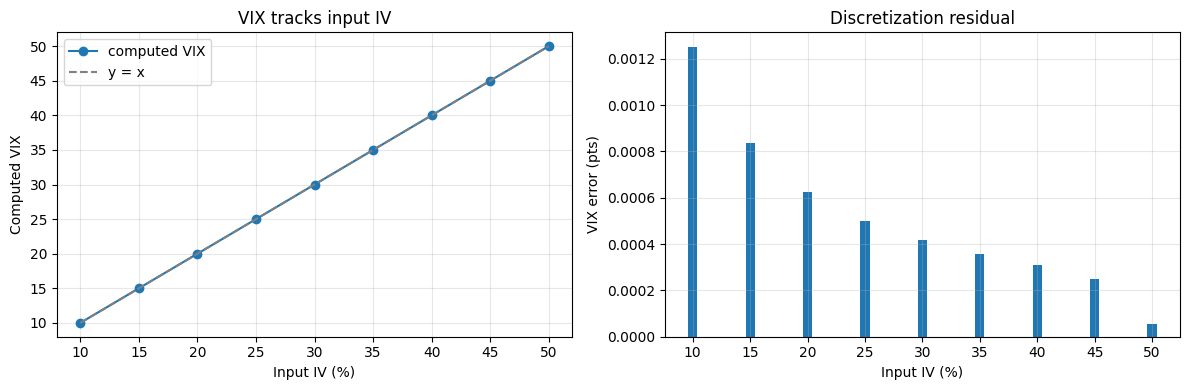

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(df['IV (%)'], df['VIX (computed)'], marker='o', label='computed VIX')
ax1.plot(df['IV (%)'], df['IV (%)'], '--', color='gray', label='y = x')
ax1.set_xlabel('Input IV (%)')
ax1.set_ylabel('Computed VIX')
ax1.set_title('VIX tracks input IV')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.bar(df['IV (%)'], df['error'])
ax2.axhline(0, color='black', lw=0.5)
ax2.set_xlabel('Input IV (%)')
ax2.set_ylabel('VIX error (pts)')
ax2.set_title('Discretization residual')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 13. Real-data backtest — TODO

Acceptance criterion: ≥95% of historical days within ±0.5 pts of the published VIX.

Pending tasks (separate issues / follow-up work):

1. **Source SPX historical option chains.** Candidates:
   - CBOE DataShop — free sample (single day) + paid bulk.
   - Wharton WRDS — academic access.
   - OptionsDX — paid commercial.
2. **Source published VIX series.** CBOE publishes daily closes; intraday available via VIX futures replicas (or DataShop intraday).
3. **Build a per-date pipeline:**
   ```python
   for date in trading_days:
       near, next_ = load_chains(date)           # ← need this
       N_T1, N_T2 = days_to_minutes(date, expiries)
       computed = compute_vix(near, next_, N_T1, N_T2)['vix']
       published = vix_series.loc[date]
       residual = computed - published
   ```
4. **Validation report:** histogram of `|residual|`, RMSE, count of days within ±0.5,
   outlier table with date, near/next expiries, strip sizes, $K_0$, $F$, $\sigma_1^2$, $\sigma_2^2$.

When data is wired, run the loop above; with the synthetic validation (§11–12)
demonstrating correct mechanics, any residual blow-ups on real data point at
**data quality** (stale quotes, missing strikes, dividend handling) rather than
the variance-swap math.
